In [24]:
import numpy as np, matplotlib.pyplot as plt, random, scipy as sp

In [25]:
#1b
p = np.array([
    [0, 1, 0, 0, 0],
    [1/3, 0, 2/3, 0, 0],
    [0, 1/2, 0, 1/2, 0],
    [0, 0, 2/3, 0, 1/3],
    [0, 0, 0, 1, 0]
])

In [26]:
vals, vecs = np.linalg.eig(p.T)
vals

array([-1.00000000e+00, -5.77350269e-01,  4.39108456e-17,  1.00000000e+00,
        5.77350269e-01])

In [27]:
pi = vecs[:, 3] / np.sum(vecs[:, 3])
pi

array([0.08333333, 0.25      , 0.33333333, 0.25      , 0.08333333])

In [28]:
#1d
q_0 = np.array([0, 0, 1, 0, 0])
np.linalg.solve(vecs, q_0)

array([-5.00000000e-01, -6.12255856e-16, -4.08248290e-01,  5.00000000e-01,
        3.92523115e-17])

In [29]:
q_0 = np.array([0, 0, 1, 0, 0])
q_50 = np.linalg.matrix_power(p.T, 50) @ q_0
q_50

array([0.16666667, 0.        , 0.66666667, 0.        , 0.16666667])

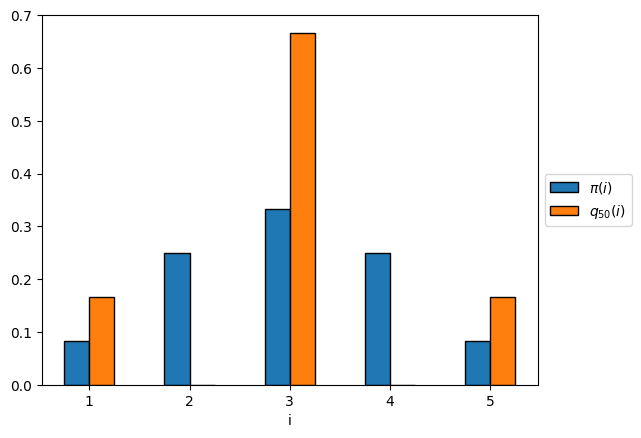

In [30]:
x = np.arange(1, 6)
w = 0.25
plt.bar(x - w / 2, pi, w, ec = "black", label = r'$\pi(i)$')
plt.bar(x + w / 2, q_50, w, ec = "black", label = r'$q_{50}(i)$')
plt.xlabel('i')
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/1d_1.png', dpi = 300, bbox_inches = 'tight')

In [31]:
#2b
p = np.array([
    [0, 1/3, 0, 1/3, 1/3, 0, 0, 0, 0],
    [1/3, 0, 1/3, 0, 1/3, 0, 0, 0, 0],
    [0, 1/2, 0, 0, 0, 1/2, 0, 0, 0],
    [1/3, 0, 0, 0, 1/3, 0, 1/3, 0, 0],
    [1/5, 1/5, 0, 1/5, 0, 1/5, 0, 1/5, 0],
    [0, 0, 1/3, 0, 1/3, 0, 0, 0, 1/3],
    [0, 0, 0, 1/2, 0, 0, 0, 1/2, 0],
    [0, 0, 0, 0, 1/3, 0, 1/3, 0, 1/3],
    [0, 0, 0, 0, 0, 1/2, 0, 1/2, 0]
])

In [32]:
vals, vecs = np.linalg.eig(p.T)
vals

array([ 1.00000000e+00, -9.07078664e-01, -5.27345175e-01, -1.89542021e-01,
        7.43204234e-02,  5.49645436e-01,  5.77350269e-01, -5.77350269e-01,
       -3.14907345e-17])

In [33]:
pi = vecs[:, 0] / np.sum(vecs[:, 0])
pi

array([0.11538462, 0.11538462, 0.07692308, 0.11538462, 0.19230769,
       0.11538462, 0.07692308, 0.11538462, 0.07692308])

In [34]:
def z_to_x(pi):
    pi_x = np.zeros(5)
    pi_x[0] = pi[0]
    pi_x[1] = pi[1] + pi[3]
    pi_x[2] = pi[2] + pi[4] + pi[6]
    pi_x[3] = pi[5] + pi[7]
    pi_x[4] = pi[8]
    return pi_x

In [35]:
z_to_x(pi)

array([0.11538462, 0.23076923, 0.34615385, 0.23076923, 0.07692308])

In [36]:
#2d
q_0_2_0 = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0])
q_50_2_0 = np.linalg.matrix_power(p.T, 50) @ q_0_2_0
q_0_1_1 = np.array([0, 0, 0, 0, 1, 0, 0, 0, 0])
q_50_1_1 = np.linalg.matrix_power(p.T, 50) @ q_0_1_1
q_0_0_2 = np.array([0, 0, 0, 0, 0, 0, 1, 0, 0])
q_50_0_2 = np.linalg.matrix_power(p.T, 50) @ q_0_0_2

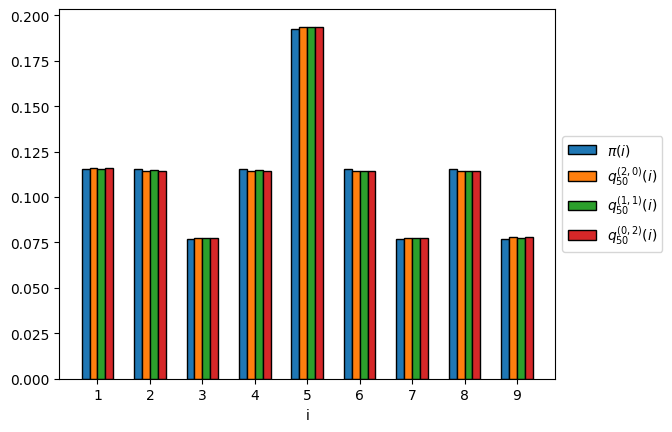

In [37]:
x = np.arange(1, 10)
w = 0.15
plt.bar(x - 3 * w / 2, pi, w, ec = "black", label = r'$\pi(i)$')
plt.bar(x - w / 2, q_50_2_0, w, ec = "black", label = r'$q_{50}^{(2,0)}(i)$')
plt.bar(x + w / 2, q_50_1_1, w, ec = "black", label = r'$q_{50}^{(1,1)}(i)$')
plt.bar(x + 3 * w / 2, q_50_0_2, w, ec = "black", label = r'$q_{50}^{(0,2)}(i)$')
plt.xticks(x)
plt.xlabel('i')
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/2d_1.png', dpi = 300, bbox_inches = 'tight')

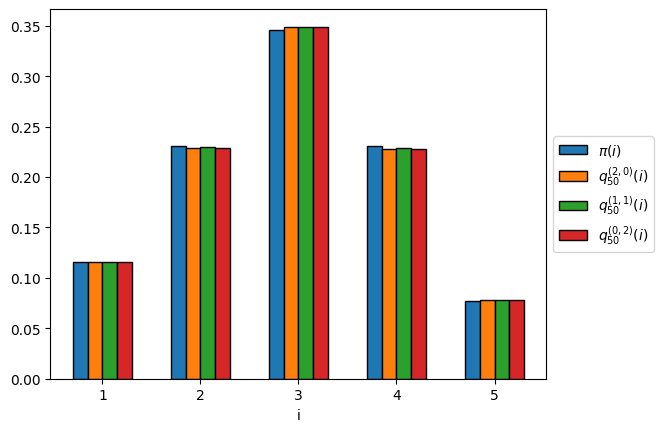

In [38]:
x = np.arange(1, 6)
w = 0.15
plt.bar(x - 3 * w / 2, z_to_x(pi), w, ec = "black", label = r'$\pi(i)$')
plt.bar(x - w / 2, z_to_x(q_50_2_0), w, ec = "black", label = r'$q_{50}^{(2,0)}(i)$')
plt.bar(x + w / 2, z_to_x(q_50_1_1), w, ec = "black", label = r'$q_{50}^{(1,1)}(i)$')
plt.bar(x + 3 * w / 2, z_to_x(q_50_0_2), w, ec = "black", label = r'$q_{50}^{(0,2)}(i)$')
plt.xticks(x)
plt.xlabel('i')
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/2d_2.png', dpi = 300, bbox_inches = 'tight')

0.20318786997997984


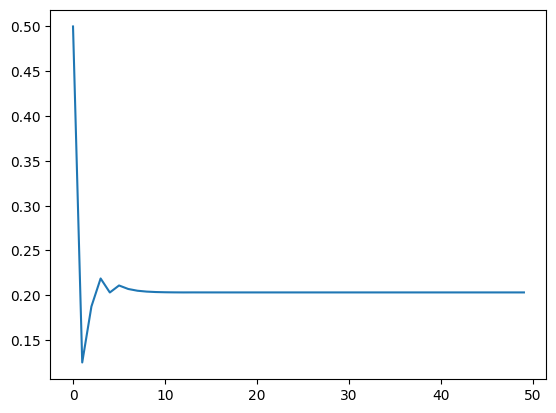

In [39]:
#3c
f = lambda x: np.log(x) - 2 * x + 2
y = [0.5]
c = 0.25
l = 0
r = 0.5
for i in range(10 ** 6):
    if f(c) == 0:
        break
    elif f(c) < 0:
        l = c
    else:
        r = c
    c = (l + r) / 2
    y.append(c)
print(c)
plt.plot(np.arange(len(y)), y)


In [40]:
#4b
rng = np.random.default_rng()
a = 0.49
x_n = np.ones(10 ** 6, dtype = int)
for n in range(200):
    x_n = 2 * rng.binomial(x_n, 1 - a)
1 - np.count_nonzero(x_n) / 10 ** 6

0.960281

In [41]:
print(a / (1 - a))

0.9607843137254901


In [42]:
#5b
def f(t):
    term_1 = 9 * t * np.exp(-3 * t) * (1 - np.exp(-2 * t) * (1 + 2 * t))
    term_2 = 4 * t * np.exp(-2 * t) * (1 - np.exp(-3 * t) * (1 + 3 * t))
    return term_1 + term_2

def integrand(t):
    return t * f(t)

In [43]:
result, error = sp.integrate.quad(integrand, 0, np.inf)
print(result)
print(error)

1.1706666666666665
1.977065663802227e-09


In [44]:
#6d
x = np.ones(10 ** 3, dtype = int)
x_n = np.ones(10 ** 3, dtype = int)
while True:
    if np.all(x_n == 0):
        break
    x_n = 2 * rng.binomial(x_n, 1/2)
    x += x_n
np.sum(x == 3) / 10 ** 3

np.float64(0.123)